286


(-1.0, 1.0)

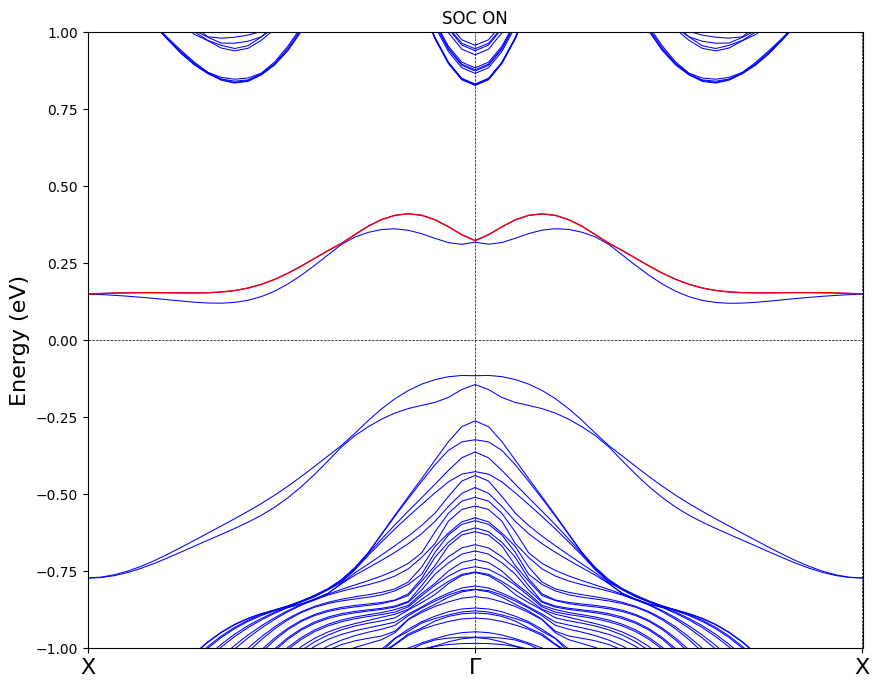

In [72]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('REFORMATTED_BAND.dat')

k = data[:, 0]
bands = data[:, 1:]
num_bands = bands.shape[1]
print(num_bands)
high_symmetry_points = [0,0.764,1.527]  
high_symmetry_labels = [ 'X', r'$\Gamma$', 'X']

plt.figure(figsize=(10, 8))
for i in range(num_bands):
    plt.plot(k, bands[:, i], color='blue',lw=0.75)

plt.plot(k, bands[:,201], color='red', lw=1)  # Fermi level

plt.axhline(0, color='black', linestyle='--', lw=0.5)
for i in range(len(high_symmetry_points)):
    plt.axvline(high_symmetry_points[i], color='black', linestyle='--', lw=0.5)

plt.xticks(high_symmetry_points, high_symmetry_labels, fontsize=16)
plt.ylabel('Energy (eV)', fontsize=16)
plt.title("SOC ON")
plt.xlim(min(k), max(k))
plt.ylim(-1, 1)

(-1.0, 1.0)

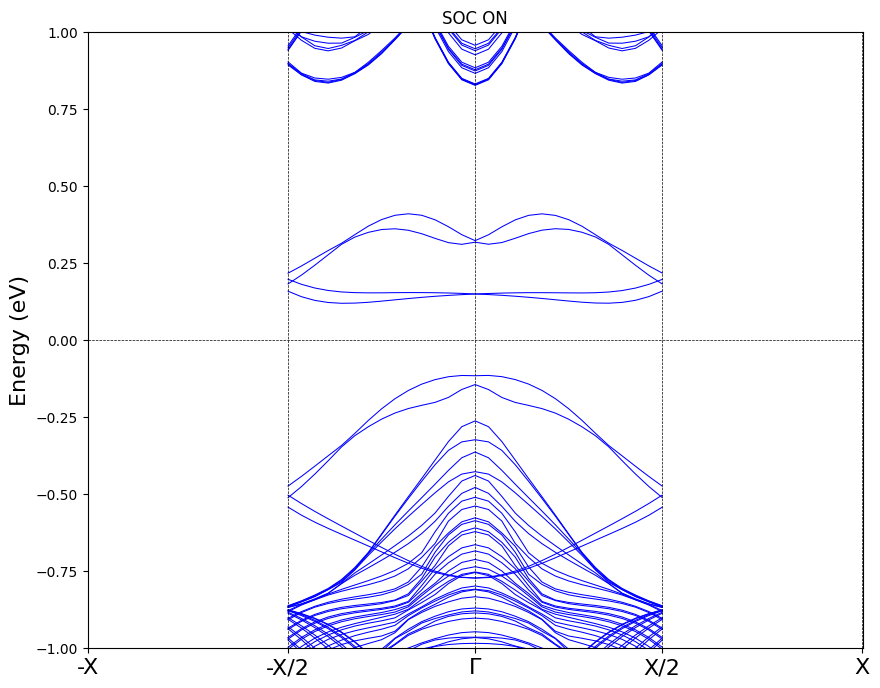

In [95]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('REFORMATTED_BAND.dat')

k = data[:, 0]
bands = data[:, 1:]
num_bands = bands.shape[1]

high_symmetry_points = [0,k[int(len(k)/4)],0.764,k[int(3*(len(k)-1)/4)],1.527]  
high_symmetry_labels = [ '-X','-X/2', r'$\Gamma$','X/2', 'X']


k_folded = k[int(len(k)/4):int(3*len(k)/4)]

bands_folded = []
for i in range(bands.shape[1]):
    add_main = bands[:,i][int(len(k)/4):int(len(k)*3/4)]
    bands_folded.append(add_main)
    left = np.array(bands[:,i][int(3*len(k)/4):int(len(k))])
    right = np.array(bands[:,i][0:int(len(k)/4)])
    add_fold = np.concatenate((left, right))
    bands_folded.append(add_fold)
    
bands_folded = np.array(bands_folded)

plt.figure(figsize=(10, 8))

for i in range(len(bands_folded)):
    plt.plot(k_folded, bands_folded[i], color='blue',lw=0.75)    

plt.axhline(0, color='black', linestyle='--', lw=0.5)
for i in range(len(high_symmetry_points)):
    plt.axvline(high_symmetry_points[i], color='black', linestyle='--', lw=0.5)

plt.xticks(high_symmetry_points, high_symmetry_labels, fontsize=16)
plt.ylabel('Energy (eV)', fontsize=16)
plt.title("SOC ON")
plt.xlim(min(k), max(k))
plt.ylim(-1, 1)